In [2]:
%pip install pandas pillow imagehash


Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import pandas as pd
from PIL import Image
import imagehash

DATASET_PATH = r"E:\Main project\Batch 15\dataset"
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

# 🔍 Check if path exists
if not os.path.exists(DATASET_PATH):
    print("ERROR: Dataset path does not exist!")
    print("Check this path:", DATASET_PATH)
    exit()

records = []

for cls in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, cls)
    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):
        if file.lower().endswith(IMAGE_EXTS):
            path = os.path.join(class_path, file)
            try:
                img = Image.open(path).convert("RGB")
                h = str(imagehash.phash(img))
                records.append([cls, file, h])
            except Exception as e:
                print("Error reading:", path)

# Create DataFrame
df = pd.DataFrame(records, columns=["Class", "Filename", "Hash"])

duplicates = df[df.duplicated(subset=["Hash"], keep=False)]

print("\nTOTAL IMAGES :", len(df))
print("TOTAL DUPLICATE GROUPS :", duplicates["Hash"].nunique())

print("\nDUPLICATE SUMMARY PER CLASS:")
print(duplicates.groupby("Class").size())

print("\nDUPLICATE FILE LIST:")
print(duplicates.sort_values("Hash"))



TOTAL IMAGES : 9774
TOTAL DUPLICATE GROUPS : 3

DUPLICATE SUMMARY PER CLASS:
Class
diabetic_retinopathy    2
glaucoma                2
normal                  2
dtype: int64

DUPLICATE FILE LIST:
                     Class          Filename              Hash
9707                normal    Healthy934.jpg  c0c512916f737ec6
9710                normal    Healthy937.jpg  c0c512916f737ec6
3419  diabetic_retinopathy         DR836.jpg  c0cd02251fc57fc7
3420  diabetic_retinopathy         DR837.jpg  c0cd02251fc57fc7
5906              glaucoma  Glaucoma1012.jpg  c1c1101e6f664fdb
5908              glaucoma  Glaucoma1015.jpg  c1c1101e6f664fdb


In [3]:
import os
import pandas as pd
from PIL import Image
import imagehash

DATASET_PATH = r"E:\Main project\Batch 15\dataset"
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

records = []

# Step 1: Read all images & compute hash
for cls in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, cls)
    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):
        if file.lower().endswith(IMAGE_EXTS):
            path = os.path.join(class_path, file)
            try:
                img = Image.open(path).convert("RGB")
                h = str(imagehash.phash(img))
                records.append([cls, file, path, h])
            except:
                pass

df = pd.DataFrame(records, columns=["Class", "Filename", "Path", "Hash"])

# Step 2: Find duplicates (keep first, delete others)
dups = df[df.duplicated(subset=["Hash"], keep="first")]

# Step 3: Delete duplicate files
for p in dups["Path"]:
    try:
        os.remove(p)
    except:
        pass

# Step 4: Final count per class
print("\nFINAL IMAGE COUNT AFTER CLEANING:\n")

for cls in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, cls)
    if not os.path.isdir(class_path):
        continue

    count = len([f for f in os.listdir(class_path) if f.lower().endswith(IMAGE_EXTS)])
    print(f"{cls} : {count} images")

print("\nTOTAL DELETED DUPLICATES :", len(dups))



FINAL IMAGE COUNT AFTER CLEANING:

cataract : 1021 images
diabetic_retinopathy : 2573 images
DME : 991 images
DME NORMAL : 1000 images
glaucoma : 2273 images
normal : 1913 images

TOTAL DELETED DUPLICATES : 3


In [4]:
import os
from PIL import Image

DATASET_PATH = r"E:\Main project\Batch 15\dataset"
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

TARGET_SIZE = (224, 224)   # you can change this

print("TARGET SIZE:", TARGET_SIZE, "\n")

for cls in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, cls)
    if not os.path.isdir(class_path):
        continue

    print(f"\nClass: {cls}")

    for file in os.listdir(class_path):
        if file.lower().endswith(IMAGE_EXTS):
            path = os.path.join(class_path, file)
            try:
                img = Image.open(path)
                old_size = img.size   # (width, height)

                img = img.resize(TARGET_SIZE)
                img.save(path)

                print(f"{file}  |  {old_size}  ->  {TARGET_SIZE}")
            except:
                print(f"Error with {file}")


TARGET SIZE: (224, 224) 


Class: cataract
0_left.jpg  |  (224, 224)  ->  (224, 224)
103_left.jpg  |  (224, 224)  ->  (224, 224)
1062_right.jpg  |  (224, 224)  ->  (224, 224)
1083_left.jpg  |  (224, 224)  ->  (224, 224)
1084_right.jpg  |  (224, 224)  ->  (224, 224)
1102_left.jpg  |  (224, 224)  ->  (224, 224)
1102_right.jpg  |  (224, 224)  ->  (224, 224)
1115_left.jpg  |  (224, 224)  ->  (224, 224)
1126_right.jpg  |  (224, 224)  ->  (224, 224)
112_right.jpg  |  (224, 224)  ->  (224, 224)
1144_left.jpg  |  (224, 224)  ->  (224, 224)
1144_right.jpg  |  (224, 224)  ->  (224, 224)
1164_left.jpg  |  (224, 224)  ->  (224, 224)
1167_right.jpg  |  (224, 224)  ->  (224, 224)
119_left.jpg  |  (224, 224)  ->  (224, 224)
1285_left.jpg  |  (224, 224)  ->  (224, 224)
1415_left.jpg  |  (224, 224)  ->  (224, 224)
1415_right.jpg  |  (224, 224)  ->  (224, 224)
1435_left.jpg  |  (224, 224)  ->  (224, 224)
1444_left.jpg  |  (224, 224)  ->  (224, 224)
1452_left.jpg  |  (224, 224)  ->  (224, 224)
1454_right

TARGET IMAGE SIZE USED IN PROJECT: (224, 224) 


Class: cataract
All images are SAME size: (224, 224)


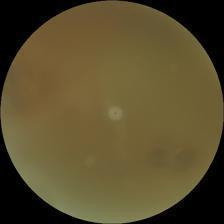


Class: diabetic_retinopathy
All images are SAME size: (224, 224)


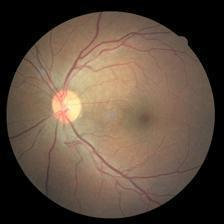


Class: DME
All images are SAME size: (224, 224)


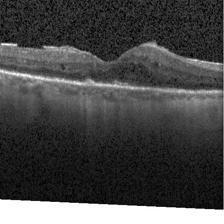


Class: DME NORMAL
All images are SAME size: (224, 224)


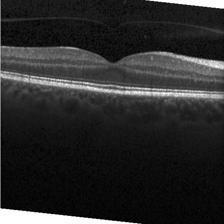


Class: glaucoma
All images are SAME size: (224, 224)


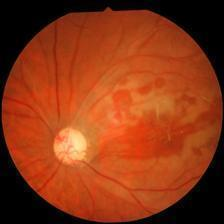


Class: normal
All images are SAME size: (224, 224)


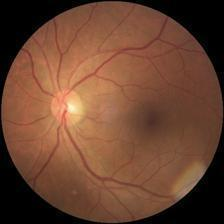

In [5]:
import os
from PIL import Image
from IPython.display import display

DATASET_PATH = r"E:\Main project\Batch 15\dataset"
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

TARGET_SIZE = (224, 224)

print("TARGET IMAGE SIZE USED IN PROJECT:", TARGET_SIZE, "\n")

for cls in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, cls)
    if not os.path.isdir(class_path):
        continue

    print(f"\nClass: {cls}")

    sizes = set()
    sample_img = None

    for file in os.listdir(class_path):
        if file.lower().endswith(IMAGE_EXTS):
            path = os.path.join(class_path, file)
            try:
                img = Image.open(path)
                sizes.add(img.size)
                if sample_img is None:
                    sample_img = img.copy()
            except:
                pass

    # Show verification result
    if len(sizes) == 1:
        print("All images are SAME size:", sizes.pop())
    else:
        print("Different sizes found:", sizes)

    # Show one sample image
    if sample_img:
        display(sample_img)


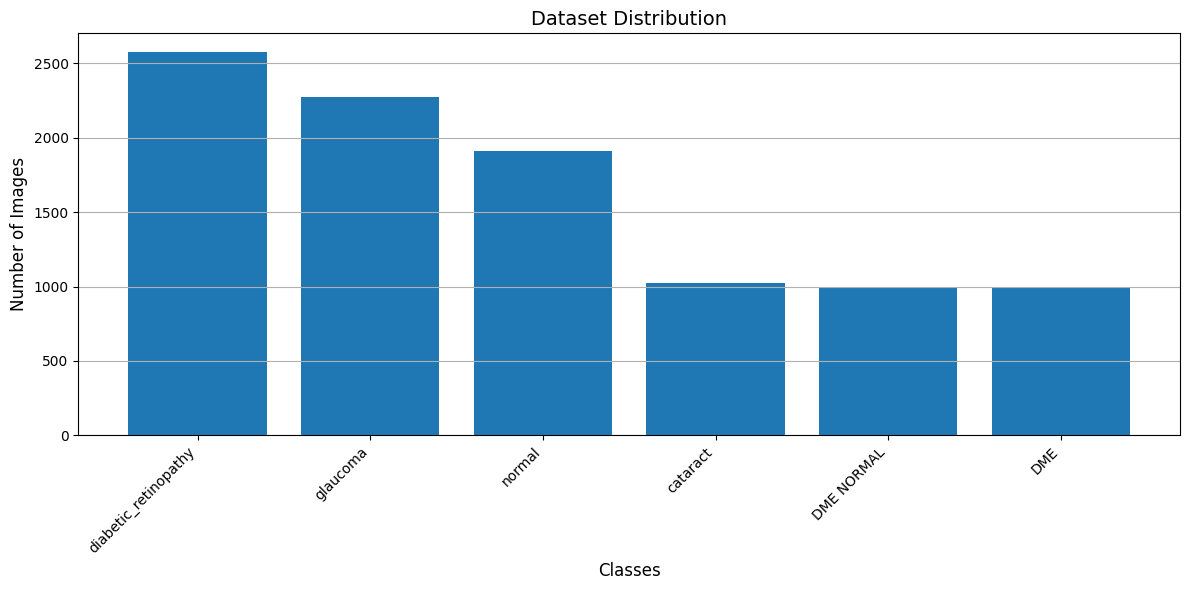

In [2]:
import os
import matplotlib.pyplot as plt

DATASET_PATH = r"E:\Main project\Batch 15\dataset"
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

class_names = []
image_counts = []

# Collect data
for cls in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, cls)
    if not os.path.isdir(class_path):
        continue

    count = len([f for f in os.listdir(class_path) if f.lower().endswith(IMAGE_EXTS)])
    class_names.append(cls)
    image_counts.append(count)

# Sort by image count (important for clean look)
sorted_data = sorted(zip(class_names, image_counts), key=lambda x: x[1], reverse=True)
class_names, image_counts = zip(*sorted_data)

# Plot (single chart, no custom colors)
plt.figure(figsize=(12, 6))
plt.bar(class_names, image_counts)

plt.xlabel("Classes", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Dataset Distribution", fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

plt.tight_layout()
plt.show()


In [4]:
import os
import pandas as pd

DATASET_PATH = r"E:\Main project\Batch 15\dataset"
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

records = []

# Walk through dataset
for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.lower().endswith(IMAGE_EXTS):
            full_path = os.path.join(root, file)
            class_name = os.path.basename(os.path.dirname(full_path))
            
            records.append({
                "filename": file,
                "filepath": full_path,
                "class": class_name
            })

# Create DataFrame
df = pd.DataFrame(records)

# Save CSV
output_path = "dataset.csv"
df.to_csv(output_path, index=False)

print("CSV file created successfully.")
print("Total images:", len(df))
print("Saved at:", os.path.abspath(output_path))


CSV file created successfully.
Total images: 9771
Saved at: e:\Main project\Batch 15\dataset.csv


In [15]:
import os
import pandas as pd

CSV_PATH = "dataset.csv"

# Load CSV
df = pd.read_csv(CSV_PATH)

print("\n===== BASIC INFO =====")
print("Total Samples:", len(df))
print("Columns:", list(df.columns))

# 1️⃣ Check required columns
required_columns = ["filepath", "class"]
for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

# 2️⃣ Check missing values
print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

# 3️⃣ Check invalid file paths
print("\n===== INVALID FILE PATHS =====")
invalid_paths = df[~df["filepath"].apply(os.path.exists)]
print("Invalid Files:", len(invalid_paths))

# 4️⃣ Check duplicate entries
print("\n===== DUPLICATES =====")
duplicates = df[df.duplicated()]
print("Duplicate Rows:", len(duplicates))

# 5️⃣ Class distribution
print("\n===== CLASS DISTRIBUTION =====")
print(df["class"].value_counts())

# 6️⃣ Class imbalance ratio
max_class = df["class"].value_counts().max()
min_class = df["class"].value_counts().min()
imbalance_ratio = max_class / min_class

print("\nImbalance Ratio:", round(imbalance_ratio, 2))

if imbalance_ratio > 2:
    print("⚠️ Dataset is imbalanced")
else:
    print("✅ Dataset is reasonably balanced")

print("\n===== VALIDATION COMPLETE =====")



===== BASIC INFO =====
Total Samples: 9771
Columns: ['filename', 'filepath', 'class']

===== MISSING VALUES =====
filename    0
filepath    0
class       0
dtype: int64

===== INVALID FILE PATHS =====
Invalid Files: 0

===== DUPLICATES =====
Duplicate Rows: 0

===== CLASS DISTRIBUTION =====
class
diabetic_retinopathy    2573
glaucoma                2273
normal                  1913
cataract                1021
DME NORMAL              1000
DME                      991
Name: count, dtype: int64

Imbalance Ratio: 2.6
⚠️ Dataset is imbalanced

===== VALIDATION COMPLETE =====


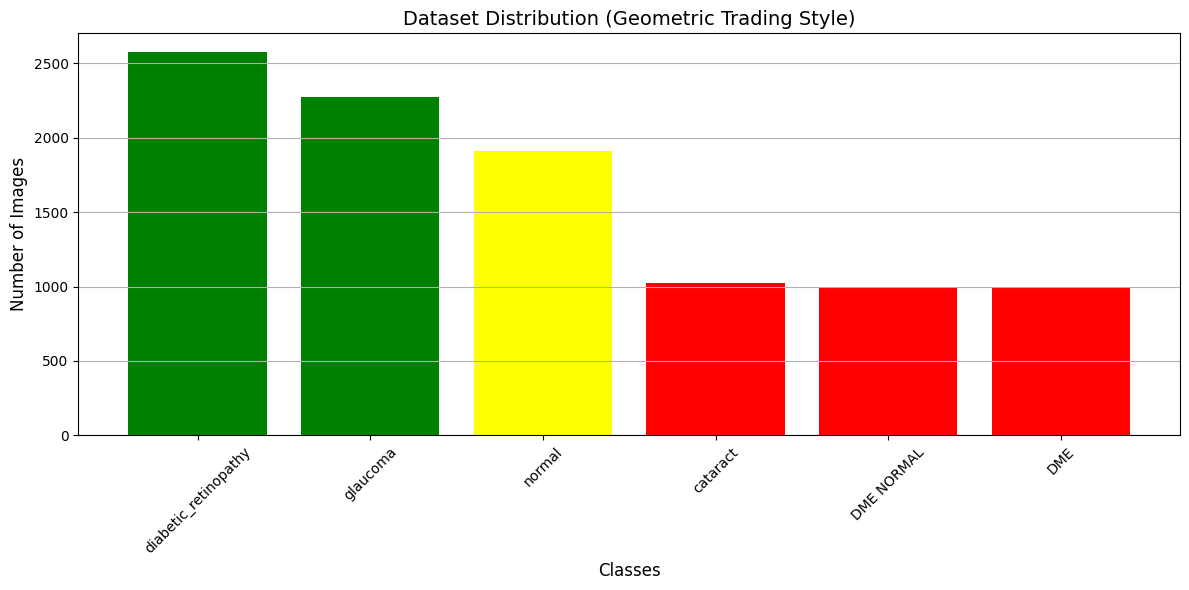

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 🔹 Load your CSV file (change path if needed)
df = pd.read_csv("dataset.csv")

# 🔹 Get class distribution
class_counts = df["class"].value_counts()

classes = class_counts.index.tolist()
counts = class_counts.values.tolist()

# 🔹 Determine thresholds
max_count = max(counts)

colors = []
for value in counts:
    if value >= max_count * 0.75:
        colors.append("green")      # High
    elif value <= max_count * 0.5:
        colors.append("red")        # Low
    else:
        colors.append("yellow")     # Medium

# 🔹 Plot (Single Chart Only)
plt.figure(figsize=(12,6))
plt.bar(classes, counts, color=colors)

plt.xlabel("Classes", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Dataset Distribution (Geometric Trading Style)", fontsize=14)

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()


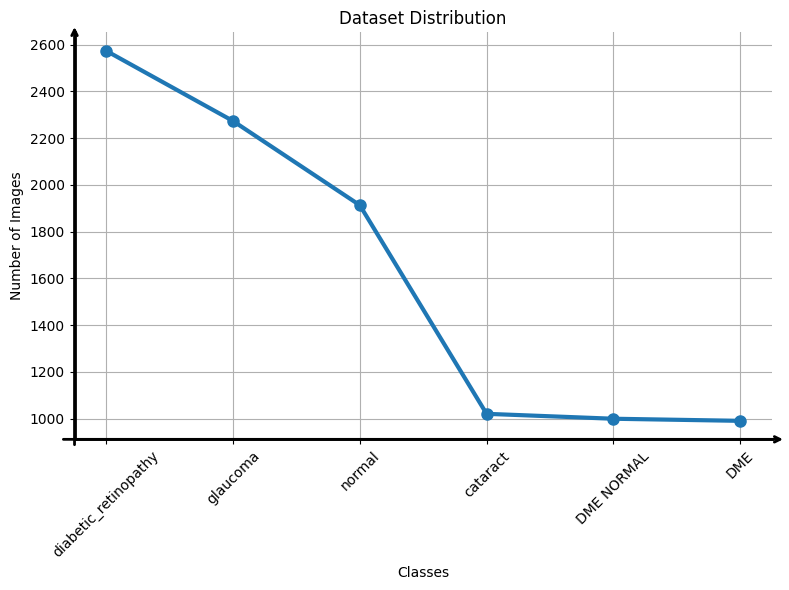

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("dataset.csv")

# Get class distribution
class_counts = df["class"].value_counts()

classes = class_counts.index.tolist()
counts = class_counts.values.tolist()

# Create figure
plt.figure(figsize=(8,6))

# Plot line with markers
plt.plot(classes, counts, marker='o', linewidth=3, markersize=8)

# Grid like geometric background
plt.grid(True)

# Labels
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution")

# Rotate x labels
plt.xticks(rotation=45)

# Thicker axis lines
ax = plt.gca()
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add arrow style to axes
ax.annotate('', xy=(1.02, 0), xycoords=('axes fraction', 'axes fraction'),
            xytext=(-0.02, 0),
            arrowprops=dict(arrowstyle="->", linewidth=2))

ax.annotate('', xy=(0, 1.02), xycoords=('axes fraction', 'axes fraction'),
            xytext=(0, -0.02),
            arrowprops=dict(arrowstyle="->", linewidth=2))

plt.tight_layout()
plt.show()


In [8]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    'balanced', 
    classes=np.unique(df['class']), 
    y=df['class']
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

# Use in model: model.fit(..., class_weight=class_weight_dict)

{0: np.float64(1.643289606458123), 1: np.float64(1.6285), 2: np.float64(1.5950048971596473), 3: np.float64(0.6329187718616401), 4: np.float64(0.7164540255169379), 5: np.float64(0.8512807109252483)}


In [12]:
import torch

# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Your class weights
class_weight_dict = {
    0: 1.643289606458123,
    1: 1.6285,
    2: 1.5950048971596473,
    3: 0.6329187718616401,
    4: 0.7164540255169379,
    5: 0.8512807109252483
}

# Convert to tensor
weights = torch.tensor([class_weight_dict[i] for i in sorted(class_weight_dict.keys())], dtype=torch.float32)

# Use in loss function
criterion = torch.nn.CrossEntropyLoss(weight=weights.to(device))

# Then in training loop:
# loss = criterion(outputs, labels)

Using device: cpu


In [13]:
import torch
import torch.nn as nn
from torch.optim import Adam

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class_weight_dict = {
    0: 1.643289606458123,
    1: 1.6285,
    2: 1.5950048971596473,
    3: 0.6329187718616401,
    4: 0.7164540255169379,
    5: 0.8512807109252483
}

weights = torch.tensor([class_weight_dict[i] for i in sorted(class_weight_dict.keys())], dtype=torch.float32)
criterion = torch.nn.CrossEntropyLoss(weight=weights.to(device))

# In your training loop:
# for epoch in range(num_epochs):
#     for images, labels in train_loader:
#         images, labels = images.to(device), labels.to(device)
#         
#         outputs = model(images)
#         loss = criterion(outputs, labels)  # Uses class weights automatically
#         
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

C:\Users\Divith Bharath\AppData\Local\Temp\ipykernel_11532\974346989.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  weighted_counts = [class_counts[i] * class_weights[i] for i in range(6)]


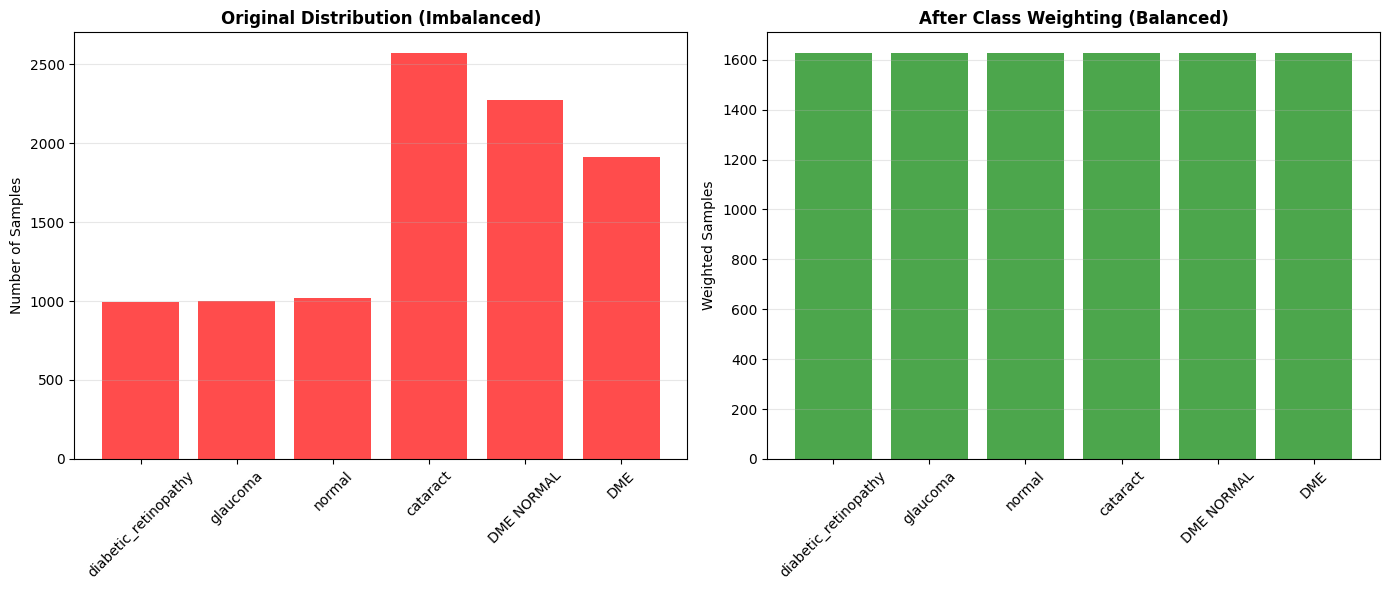


===== CLASS BALANCE CHECK =====

Class                Original     Weight       Weighted    
--------------------------------------------------------
diabetic_retinopathy 991          1.6433       1628.50     
glaucoma             1000         1.6285       1628.50     
normal               1021         1.5950       1628.50     
cataract             2573         0.6329       1628.50     
DME NORMAL           2273         0.7165       1628.50     
DME                  1913         0.8513       1628.50     

✅ Classes are now effectively balanced for training!


C:\Users\Divith Bharath\AppData\Local\Temp\ipykernel_11532\974346989.py:52: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{class_names[i]:<20} {class_counts[i]:<12} {class_weights[i]:<12.4f} {weighted_counts[i]:<12.2f}")


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV
df = pd.read_csv("dataset.csv")

# Get class distribution
class_counts = df["class"].value_counts().sort_index()

# Map index to class names
class_names = ['diabetic_retinopathy', 'glaucoma', 'normal', 'cataract', 'DME NORMAL', 'DME']

# Your class weights
class_weights = {
    0: 1.643289606458123,
    1: 1.6285,
    2: 1.5950048971596473,
    3: 0.6329187718616401,
    4: 0.7164540255169379,
    5: 0.8512807109252483
}

# Calculate weighted counts (what model "sees")
weighted_counts = [class_counts[i] * class_weights[i] for i in range(6)]

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Original distribution
ax1.bar(class_names, class_counts.values, color='red', alpha=0.7)
ax1.set_title("Original Distribution (Imbalanced)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Number of Samples")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Weighted distribution
ax2.bar(class_names, weighted_counts, color='green', alpha=0.7)
ax2.set_title("After Class Weighting (Balanced)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Weighted Samples")
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison table
print("\n===== CLASS BALANCE CHECK =====\n")
print(f"{'Class':<20} {'Original':<12} {'Weight':<12} {'Weighted':<12}")
print("-" * 56)
for i in range(6):
    print(f"{class_names[i]:<20} {class_counts[i]:<12} {class_weights[i]:<12.4f} {weighted_counts[i]:<12.2f}")

print("\n✅ Classes are now effectively balanced for training!")

In [16]:
import os
import pandas as pd
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

CSV_PATH = "dataset.csv"

# Load CSV
df = pd.read_csv(CSV_PATH)

print("\n===== BASIC INFO =====")
print("Total Samples:", len(df))
print("Columns:", list(df.columns))

# 1️⃣ Check required columns
required_columns = ["filepath", "class"]
for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

# 2️⃣ Check missing values
print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

# 3️⃣ Check invalid file paths
print("\n===== INVALID FILE PATHS =====")
invalid_paths = df[~df["filepath"].apply(os.path.exists)]
print("Invalid Files:", len(invalid_paths))

# 4️⃣ Check duplicate entries
print("\n===== DUPLICATES =====")
duplicates = df[df.duplicated()]
print("Duplicate Rows:", len(duplicates))

# 5️⃣ Class distribution
print("\n===== CLASS DISTRIBUTION =====")
print(df["class"].value_counts())

# 6️⃣ Class imbalance ratio (BEFORE weighting)
max_class = df["class"].value_counts().max()
min_class = df["class"].value_counts().min()
imbalance_ratio = max_class / min_class

print("\nImbalance Ratio (RAW):", round(imbalance_ratio, 2))
print("⚠️ Dataset is imbalanced (will be balanced with class weights during training)")

# 7️⃣ Calculate and show class weights
print("\n===== CLASS WEIGHTS (FOR BALANCED TRAINING) =====")
class_weights = compute_class_weight(
    'balanced', 
    classes=np.unique(df['class']), 
    y=df['class']
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)
print("\n✅ Class weights computed - dataset will be balanced during training!")

print("\n===== VALIDATION COMPLETE =====")


===== BASIC INFO =====
Total Samples: 9771
Columns: ['filename', 'filepath', 'class']

===== MISSING VALUES =====
filename    0
filepath    0
class       0
dtype: int64

===== INVALID FILE PATHS =====
Invalid Files: 0

===== DUPLICATES =====
Duplicate Rows: 0

===== CLASS DISTRIBUTION =====
class
diabetic_retinopathy    2573
glaucoma                2273
normal                  1913
cataract                1021
DME NORMAL              1000
DME                      991
Name: count, dtype: int64

Imbalance Ratio (RAW): 2.6
⚠️ Dataset is imbalanced (will be balanced with class weights during training)

===== CLASS WEIGHTS (FOR BALANCED TRAINING) =====
{0: np.float64(1.643289606458123), 1: np.float64(1.6285), 2: np.float64(1.5950048971596473), 3: np.float64(0.6329187718616401), 4: np.float64(0.7164540255169379), 5: np.float64(0.8512807109252483)}

✅ Class weights computed - dataset will be balanced during training!

===== VALIDATION COMPLETE =====


In [17]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 1️⃣ Image Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# 2️⃣ Load Full Dataset
dataset = datasets.ImageFolder(root="dataset", transform=transform)

# 3️⃣ Calculate Split Sizes
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size  # Remaining 15%

# 4️⃣ Split Dataset
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

# 5️⃣ Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 6839
Validation samples: 1465
Testing samples: 1467


In [18]:
torch.manual_seed(42)

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

In [20]:
model = models.resnet18(pretrained=True)

c:\Users\Divith Bharath\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Divith Bharath\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Divith Bharath/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:13<00:00, 3.56MB/s]


In [21]:
for param in model.parameters():
    param.requires_grad = False

In [22]:
num_classes = len(dataset.classes)
print("Number of classes:", num_classes)

Number of classes: 6


In [23]:
model.fc = nn.Linear(model.fc.in_features, num_classes)

In [24]:
criterion = nn.CrossEntropyLoss()

In [25]:
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [27]:
model = models.resnet18(pretrained=True)

In [28]:
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

In [32]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import time

from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
dataset = datasets.ImageFolder(root="dataset", transform=transform)

total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

torch.manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(dataset.classes)
print("Classes:", dataset.classes)
print("Number of classes:", num_classes)

Classes: ['DME', 'DME NORMAL', 'cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Number of classes: 6


In [7]:
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

In [8]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.fc.parameters(), lr=0.0001)

In [9]:
num_epochs = 25

for epoch in range(num_epochs):
    
    start_time = time.time()
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")

    for images, labels in progress_bar:
        
        images = images.to(device)
        labels = labels.to(device)

        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        progress_bar.set_postfix(
            loss=running_loss / (total / 32),
            acc=100 * correct / total
        )

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    epoch_time = time.time() - start_time

    print("\n" + "="*60)
    print(f"Epoch {epoch+1} Summary")
    print(f"Loss      : {epoch_loss:.4f}")
    print(f"Accuracy  : {epoch_acc:.2f}%")
    print(f"Time      : {epoch_time:.2f} sec")
    print("="*60)

Epoch [1/25]: 100%|██████████| 214/214 [04:43<00:00,  1.32s/it, acc=44.4, loss=1.34]



Epoch 1 Summary
Loss      : 1.3401
Accuracy  : 44.36%
Time      : 283.21 sec


Epoch [2/25]: 100%|██████████| 214/214 [02:15<00:00,  1.58it/s, acc=61.3, loss=1.01]



Epoch 2 Summary
Loss      : 1.0068
Accuracy  : 61.28%
Time      : 135.31 sec


Epoch [3/25]: 100%|██████████| 214/214 [02:18<00:00,  1.54it/s, acc=67.9, loss=0.88] 


...


Epoch 23 Summary
Loss      : 0.5297
Accuracy  : 79.60%
Time      : 163.01 sec


Epoch [24/25]: 100%|██████████| 214/214 [02:37<00:00,  1.36it/s, acc=79.5, loss=0.527]



Epoch 24 Summary
Loss      : 0.5263
Accuracy  : 79.47%
Time      : 157.91 sec


Epoch [25/25]: 100%|██████████| 214/214 [02:39<00:00,  1.35it/s, acc=80.1, loss=0.522]


Epoch 25 Summary
Loss      : 0.5212
Accuracy  : 80.07%
Time      : 159.04 sec


In [20]:
torch.save(model.state_dict(), "eye-18.pth")
print("Model saved successfully as eye-18.pth")

Model saved successfully as eye-18.pth


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Evaluation on Validation Set
model.eval()
val_correct = 0
val_total = 0
val_predictions = []
val_true_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()
        
        val_predictions.extend(predicted.cpu().numpy())
        val_true_labels.extend(labels.cpu().numpy())

val_accuracy = 100 * val_correct / val_total
print("="*60)
print("VALIDATION SET RESULTS")
print("="*60)
print(f"Accuracy: {val_accuracy:.2f}%")
print(f"Correct: {val_correct}/{val_total}")


In [ ]:
# 2️⃣ Detailed Metrics for Validation Set
val_precision = precision_score(val_true_labels, val_predictions, average='weighted', zero_division=0)
val_recall = recall_score(val_true_labels, val_predictions, average='weighted', zero_division=0)
val_f1 = f1_score(val_true_labels, val_predictions, average='weighted', zero_division=0)

print(f"Precision: {val_precision:.4f}")
print(f"Recall: {val_recall:.4f}")
print(f"F1-Score: {val_f1:.4f}")
print("="*60)


In [ ]:
# 3️⃣ Evaluation on Test Set
model.eval()
test_correct = 0
test_total = 0
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        
        test_predictions.extend(predicted.cpu().numpy())
        test_true_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * test_correct / test_total

print("="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"Accuracy: {test_accuracy:.2f}%")
print(f"Correct: {test_correct}/{test_total}")

test_precision = precision_score(test_true_labels, test_predictions, average='weighted', zero_division=0)
test_recall = recall_score(test_true_labels, test_predictions, average='weighted', zero_division=0)
test_f1 = f1_score(test_true_labels, test_predictions, average='weighted', zero_division=0)

print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")
print("="*60)


In [ ]:
# 4️⃣ Confusion Matrix
cm = confusion_matrix(test_true_labels, test_predictions)
class_names = dataset.classes

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# 5️⃣ Per-Class Metrics
print("\nPER-CLASS RESULTS (Test Set):")
print("="*80)
print(classification_report(test_true_labels, test_predictions, 
                          target_names=class_names, digits=4))
print("="*80)


In [ ]:
# 6️⃣ Load Saved Model & Make Predictions
weights = ResNet18_Weights.DEFAULT
loaded_model = resnet18(weights=weights)
loaded_model.fc = nn.Linear(loaded_model.fc.in_features, num_classes)
loaded_model.load_state_dict(torch.load("eye-18.pth"))
loaded_model = loaded_model.to(device)
loaded_model.eval()

# Predict on a sample from test set
sample_batch, sample_labels = next(iter(test_loader))
sample_batch = sample_batch.to(device)
sample_labels = sample_labels.to(device)

with torch.no_grad():
    outputs = loaded_model(sample_batch)
    probabilities = nn.functional.softmax(outputs, dim=1)
    _, predicted = torch.max(outputs, 1)

# Display results
print("\n" + "="*60)
print("SAMPLE PREDICTIONS FROM TEST SET")
print("="*60)

for i in range(min(5, len(sample_batch))):
    true_class = class_names[sample_labels[i]]
    pred_class = class_names[predicted[i]]
    confidence = probabilities[i][predicted[i]].item() * 100
    
    status = "✅" if sample_labels[i] == predicted[i] else "❌"
    print(f"{status} True: {true_class:20} | Predicted: {pred_class:20} | Confidence: {confidence:.2f}%")

print("="*60)


In [ ]:
# 7️⃣ Results Summary Chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
val_metrics = [val_accuracy/100, val_precision, val_recall, val_f1]
test_metrics = [test_accuracy/100, test_precision, test_recall, test_f1]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax.bar(x - width/2, val_metrics, width, label='Validation', alpha=0.8)
bars2 = ax.bar(x + width/2, test_metrics, width, label='Test', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Summary', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.set_ylim([0, 1.1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
# 8️⃣ Predict on Custom Image
from PIL import Image

def predict_image(image_path):
    """Predict class for a single image"""
    img = Image.open(image_path).convert("RGB")
    
    # Apply same transform used in training
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = loaded_model(img_tensor)
        probabilities = nn.functional.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
    
    pred_class = class_names[predicted.item()]
    confidence_score = confidence.item() * 100
    
    return pred_class, confidence_score, img

# Example: Predict on first image from test set
# image_path = "path/to/your/image.jpg"
# pred_class, confidence, img = predict_image(image_path)
# 
# print(f"Predicted Class: {pred_class}")
# print(f"Confidence: {confidence:.2f}%")
# 
# plt.figure(figsize=(6, 6))
# plt.imshow(img)
# plt.title(f"Prediction: {pred_class} ({confidence:.2f}%)")
# plt.axis('off')
# plt.show()
